<a href="https://colab.research.google.com/github/aatayo/aatayo.github.io/blob/main/P2_Physics_Informed_Neural_Network_(PINN)_for_Cooling_2D_Fin_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2D PINN Cooling Fin Simulation
Thermal diffusivity   α = 8.23e-05 m²/s
Fin geometry          L × W = 1.0 m × 0.1 m
Simulation time       t_max = 500.0 s
2D Physics-Informed Neural Network — Aluminum Cooling Fin

Training data summary:
  PDE collocation : 12000
  Initial cond.   : 2000
  Base BC (x=0)   : 600
  Tip BC  (x=L)   : 600
  Sym  BC (y=0)   : 400
  Side BC (y=W)   : 400

Network architecture: [3, 80, 80, 80, 80, 80, 1]

Starting 2D PINN training...
  Epoch     0 | Total=3.43e+07 | PDE=6.18e+09 | IC=1.37e+03 | BC=3.43e+07 | t=4.5s
  Epoch  2000 | Total=3.41e+03 | PDE=1.69e+09 | IC=1.57e+03 | BC=1.82e+03 | t=1276.5s
  Epoch  4000 | Total=3.17e+03 | PDE=1.40e+09 | IC=1.38e+03 | BC=1.77e+03 | t=2511.0s
  Epoch  6000 | Total=2.44e+03 | PDE=1.26e+09 | IC=1.22e+03 | BC=1.21e+03 | t=3746.7s
  Epoch  8000 | Total=1.86e+03 | PDE=9.68e+08 | IC=9.19e+02 | BC=9.37e+02 | t=4985.0s
  Epoch 10000 | Total=1.45e+03 | PDE=1.30e+09 | IC=6.98e+02 | BC=7.40e+02 | t=6223.6s
  Epoch 12000 | Total=1.1

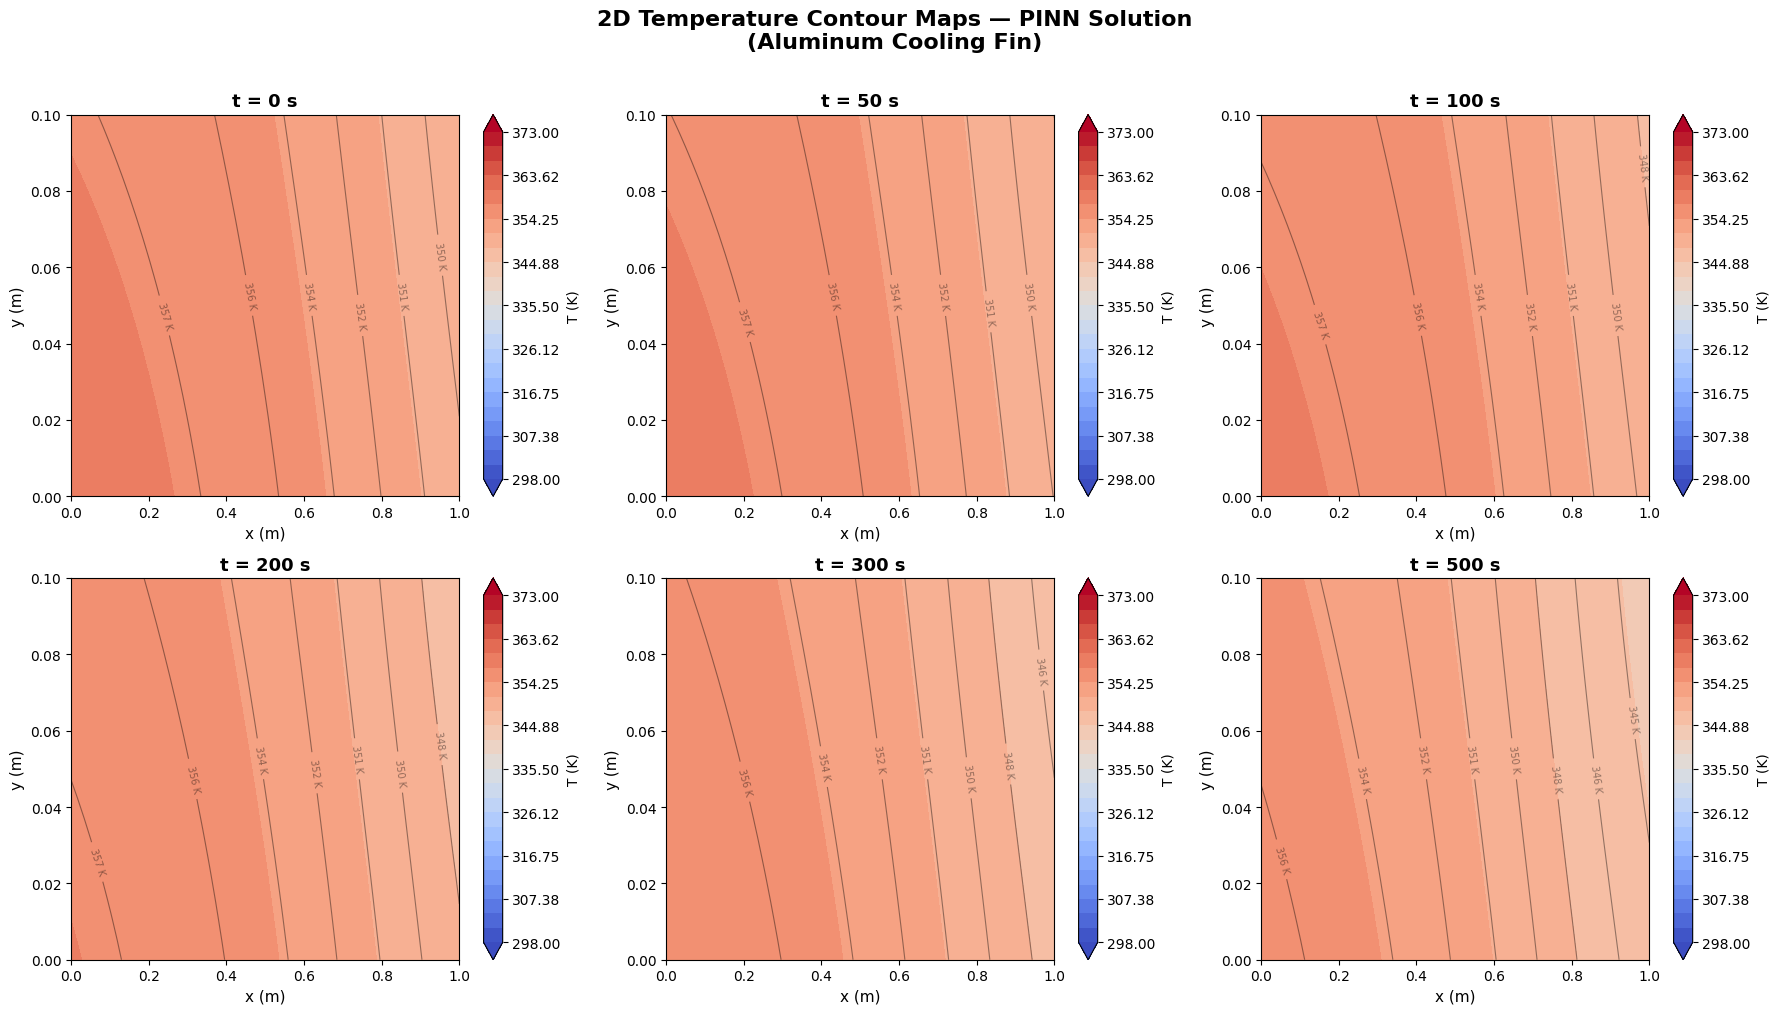

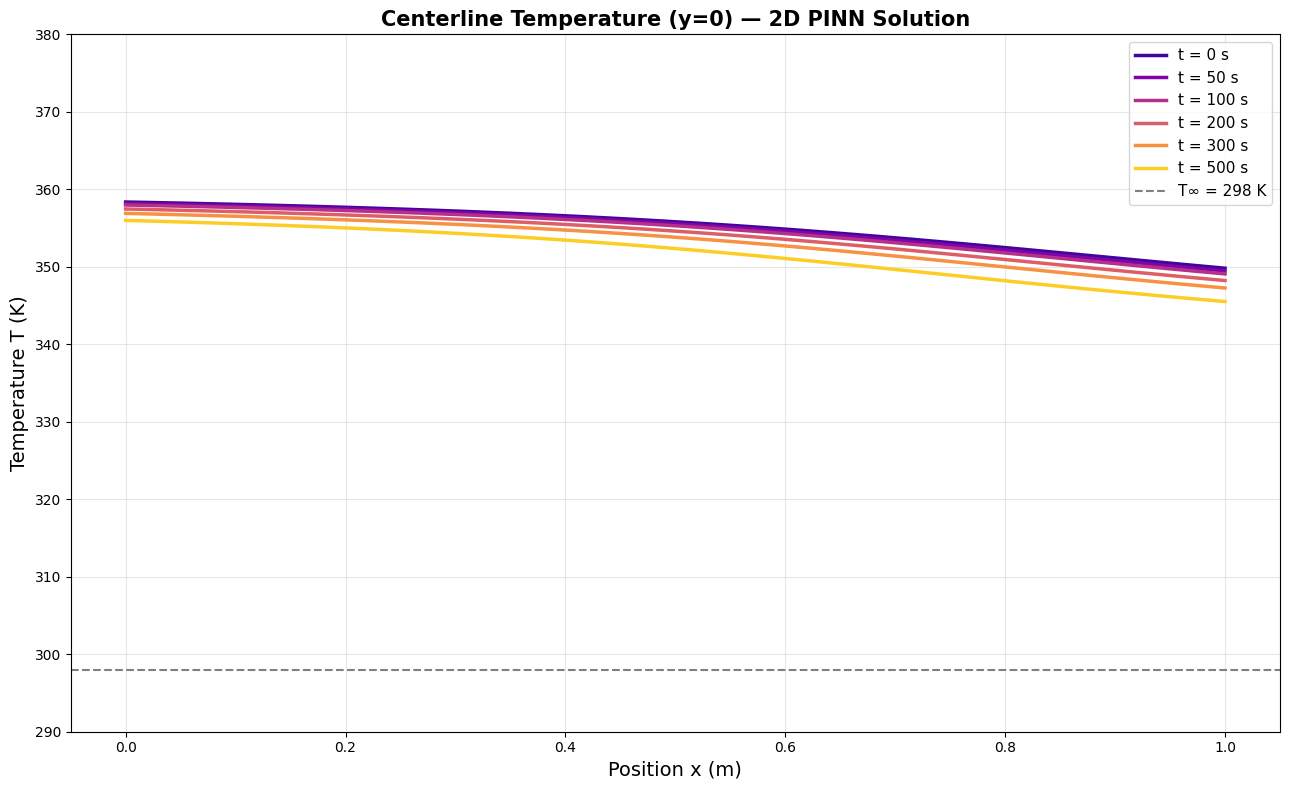

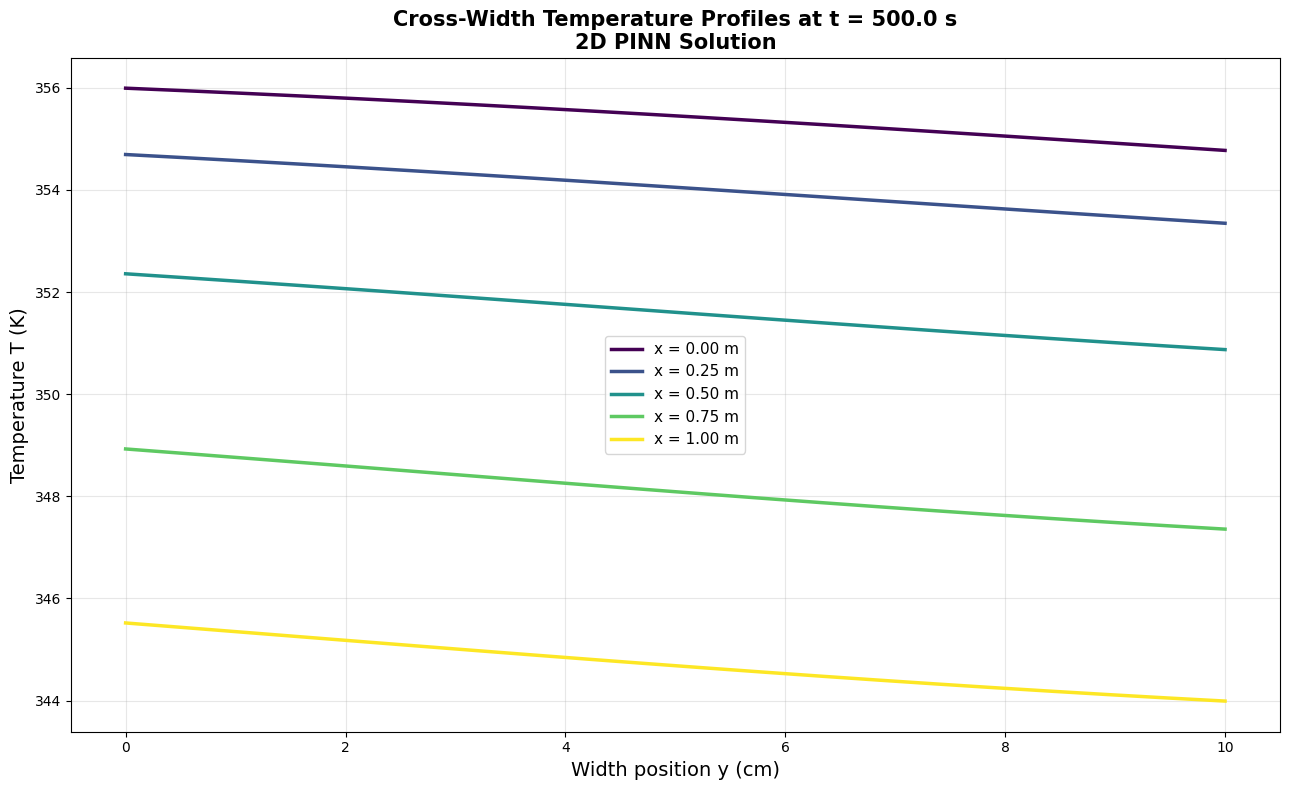

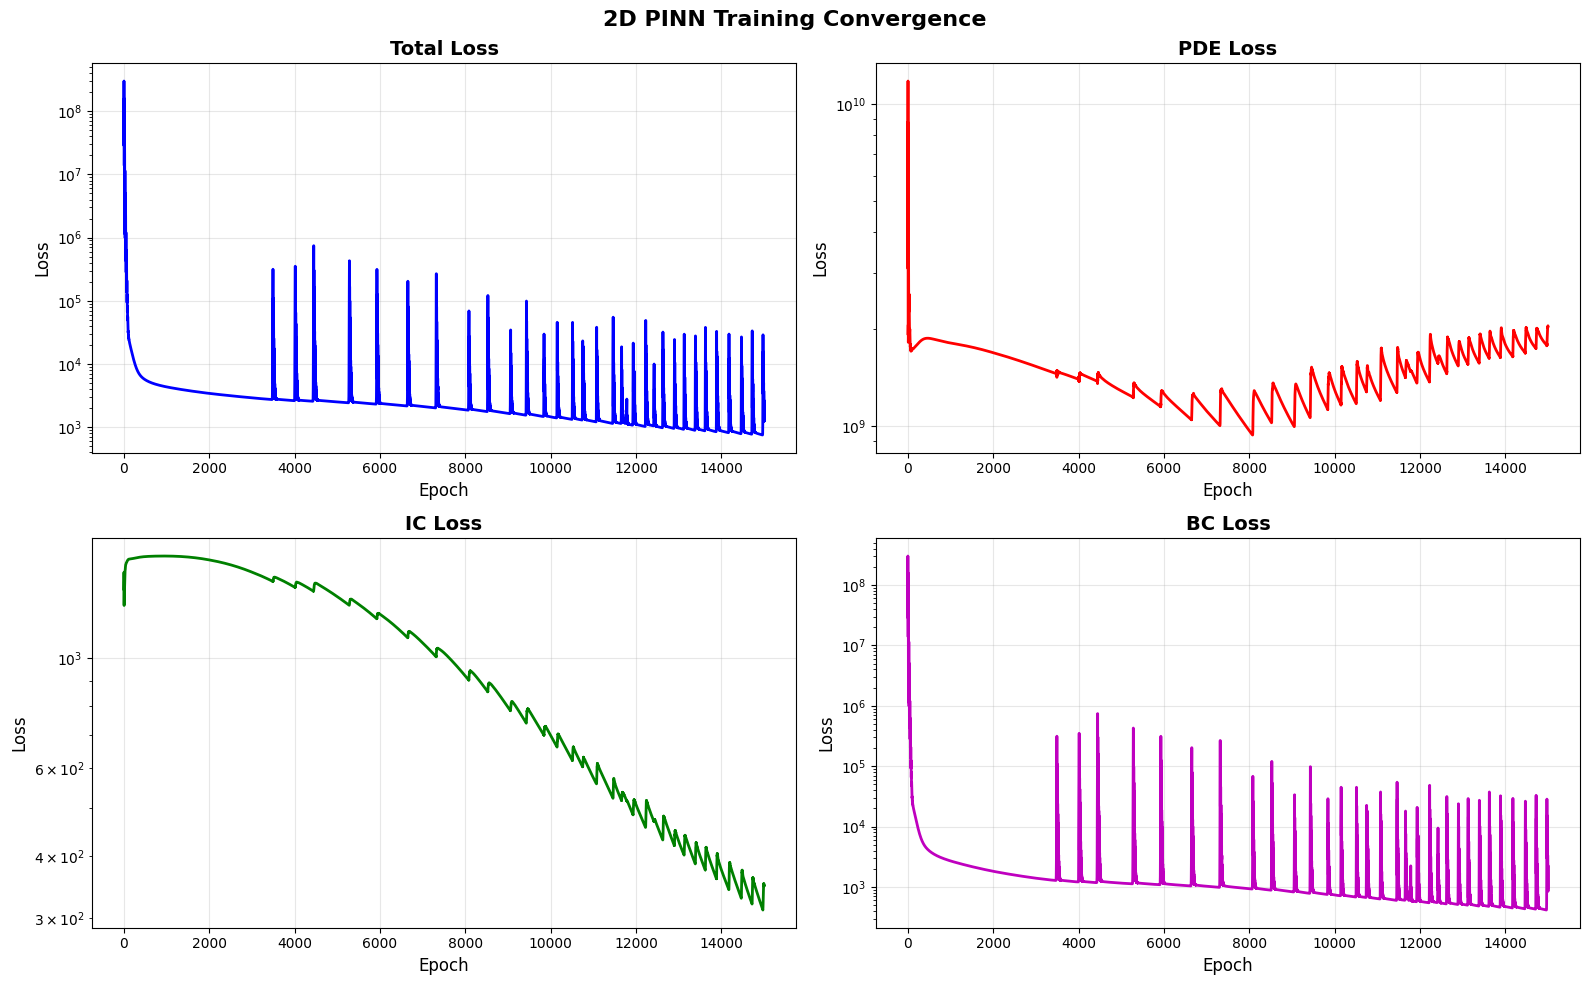

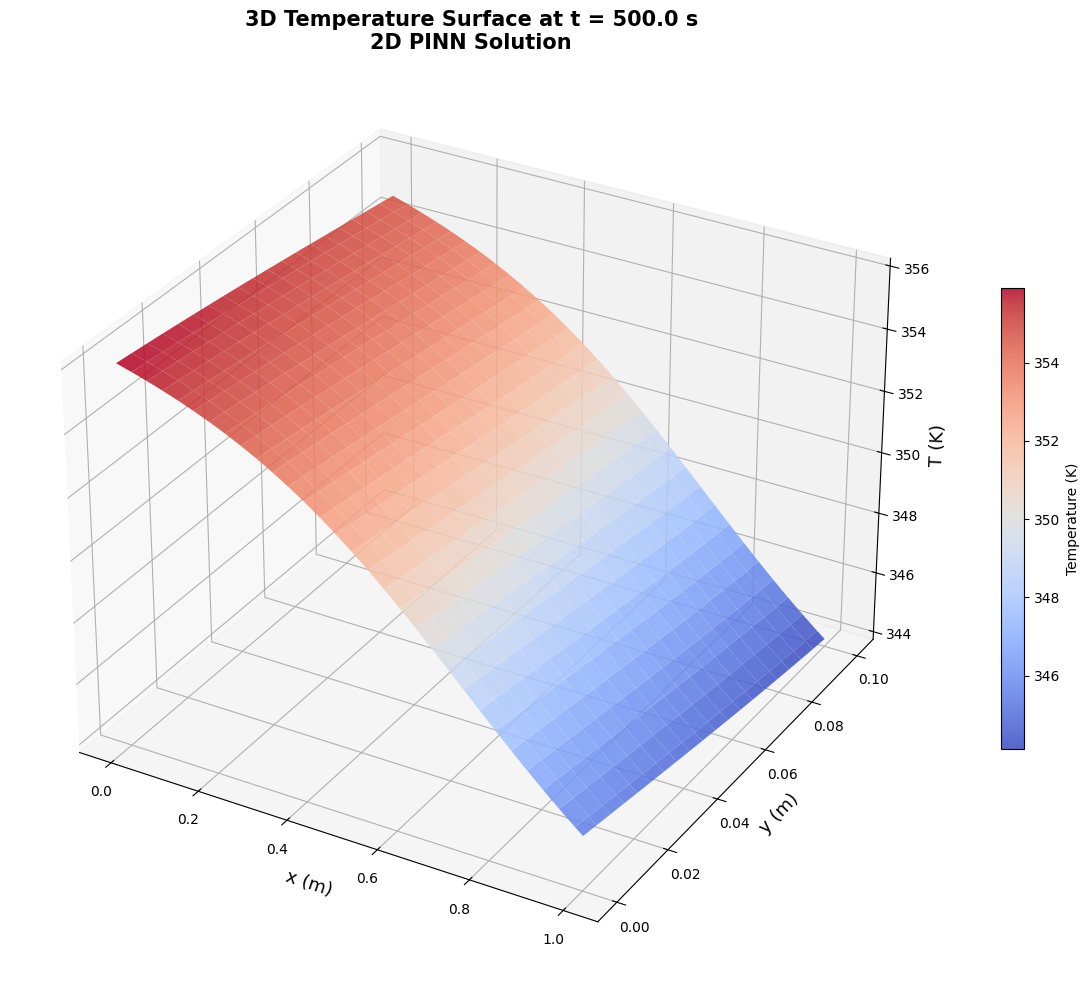


2D HEAT TRANSFER ANALYSIS
Biot number (x):   Bi_x = 0.2500
Biot number (y):   Bi_y = 0.0250
Fourier number:    Fo   = 0.04

Final State (t = 500.0 s):
  Max temperature : 355.99 K  (82.84°C)
  Min temperature : 343.99 K  (70.84°C)
  Avg temperature : 350.98 K  (77.83°C)
  Temperature drop: 12.00 K
  Fin effectiveness: 0.706
  Cooling efficiency: 29.4%

Final training loss: 1.27e+03

Output files:
  - 2d_pinn_contour_snapshots.png
  - 2d_pinn_centerline_profiles.png
  - 2d_pinn_crosswidth_profiles.png
  - 2d_pinn_convergence.png
  - 2d_pinn_3d_surface.png


In [1]:
# =============================================================================
# Physics-Informed Neural Network (PINN) for 2D Cooling Fin Heat Transfer
# =============================================================================
# This script extends the 1D PINN formulation to a fully two-dimensional
# aluminum cooling fin. The network solves the transient 2D heat conduction
# PDE with convective losses along all exposed surfaces. Input dimensions
# are (x, y, t) and the output is the temperature field T(x, y, t).
#
# Governing PDE:
#   ρ·cₚ · ∂T/∂t = k·(∂²T/∂x² + ∂²T/∂y²) - (h·P/A)·(T - T∞)
#
# Boundary Conditions:
#   T(0, y, t)   = T_base      (Dirichlet: heated base at x=0)
#   ∂T/∂x|_{x=L} = -h/k·(T - T∞)  (Robin: convective tip at x=L)
#   ∂T/∂y|_{y=0} = 0               (Neumann: symmetry at y=0)
#   ∂T/∂y|_{y=W} = -h/k·(T - T∞)  (Robin: convective side at y=W)
#
# Initial Condition:
#   T(x, y, 0) = T_initial     (Uniform initial temperature)
# =============================================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
warnings.filterwarnings('ignore')

# --- Plotting Configuration ---
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# --- Reproducibility ---
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PHYSICAL PARAMETERS (2D Aluminum Fin)
# =============================================================================
rho    = 2700.0    # Density [kg/m³]
c_p    = 900.0     # Specific heat capacity [J/(kg·K)]
k      = 200.0     # Thermal conductivity [W/(m·K)]
h      = 50.0      # Convective heat transfer coefficient [W/(m²·K)]
T_inf  = 298.0     # Ambient temperature [K] = 25°C
L      = 1.0       # Fin length in x-direction [m]
W      = 0.1       # Fin width in y-direction [m]
t_max  = 500.0     # Simulation time [s] (reduced for 2D tractability)
A_cs   = W         # Cross-sectional area per unit depth [m²/m] simplified as width
P_cs   = 2.0       # Effective perimeter factor for convective term (normalized)

# --- Initial and Boundary Temperatures ---
T_initial = 373.0  # Initial uniform temperature [K] = 100°C
T_base    = 373.0  # Fixed base temperature at x=0 [K]

# --- Derived Parameters ---
alpha  = k / (rho * c_p)           # Thermal diffusivity [m²/s]
m2     = h / (k * W)               # Fin parameter squared (simplified 2D) [1/m²]

print("=" * 70)
print("2D PINN Cooling Fin Simulation")
print("=" * 70)
print(f"Thermal diffusivity   α = {alpha:.2e} m²/s")
print(f"Fin geometry          L × W = {L} m × {W} m")
print(f"Simulation time       t_max = {t_max} s")


# =============================================================================
# 2D PINN CLASS
# =============================================================================
class CoolingFin2DPINN:
    def __init__(self, layers, lb, ub):
        """
        2D Physics-Informed Neural Network for transient fin heat transfer.

        Args:
            layers : List[int] - network architecture [3, ..., 1]
                     Input has 3 dimensions: (x, y, t)
                     Output has 1 dimension: T(x, y, t)
            lb     : List[float] - lower bounds [x_min, y_min, t_min]
            ub     : List[float] - upper bounds [x_max, y_max, t_max]
        """
        self.layers = layers
        self.lb     = tf.constant(lb, dtype=tf.float32)
        self.ub     = tf.constant(ub, dtype=tf.float32)

        # Loss tracking containers
        self.loss_history     = []
        self.pde_loss_history = []
        self.ic_loss_history  = []
        self.bc_loss_history  = []

        # Initialize network parameters
        self.weights, self.biases = self._initialize_network()

    def _initialize_network(self):
        """
        Xavier initialization for all weight matrices and zero initialization
        for all bias vectors across the full network depth.
        """
        weights, biases = [], []
        for i in range(len(self.layers) - 1):
            fan_in  = self.layers[i]
            fan_out = self.layers[i + 1]
            # Xavier scale: prevents vanishing/exploding gradients in deep nets
            scale = np.sqrt(2.0 / (fan_in + fan_out))
            w = tf.Variable(
                tf.random.normal([fan_in, fan_out], dtype=tf.float32) * scale,
                trainable=True
            )
            b = tf.Variable(tf.zeros([fan_out], dtype=tf.float32), trainable=True)
            weights.append(w)
            biases.append(b)
        return weights, biases

    def neural_net(self, X):
        """
        Forward pass through the network.

        Normalizes 3D input (x, y, t) to [-1, 1], applies tanh activations
        through hidden layers, and maps output to physical temperature range
        using sigmoid scaling.

        Args:
            X : tf.Tensor [N, 3] - stacked [x, y, t] inputs

        Returns:
            T : tf.Tensor [N, 1] - predicted temperature field
        """
        # Normalize inputs to [-1, 1] using domain bounds
        X_norm = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0

        H = X_norm
        # Hidden layers: tanh activation ensures smooth, differentiable outputs
        for i in range(len(self.weights) - 1):
            H = tf.tanh(tf.matmul(H, self.weights[i]) + self.biases[i])

        # Output layer: linear combination
        raw = tf.matmul(H, self.weights[-1]) + self.biases[-1]

        # Sigmoid scaling constrains output to physical range [T_inf, T_initial]
        T = T_inf + (T_initial - T_inf) * tf.sigmoid(raw)
        return T

    def pde_residual(self, x, y, t):
        """
        Compute 2D transient heat conduction PDE residual using nested
        automatic differentiation (AD) through TensorFlow GradientTape.

        PDE: ρ·cₚ · ∂T/∂t = k·(∂²T/∂x² + ∂²T/∂y²) - h·(2/W)·(T - T∞)
             where 2/W accounts for convection from both flat faces of the fin.

        Returns:
            residual : tf.Tensor [N, 1] - PDE violation at each collocation point
            T        : tf.Tensor [N, 1] - predicted temperatures
        """
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x, y, t])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x, y, t])
                X = tf.concat([x, y, t], axis=1)
                T = self.neural_net(X)

            # First-order derivatives
            T_x = tape1.gradient(T, x)   # ∂T/∂x
            T_y = tape1.gradient(T, y)   # ∂T/∂y
            T_t = tape1.gradient(T, t)   # ∂T/∂t

        # Second-order spatial derivatives
        T_xx = tape2.gradient(T_x, x)   # ∂²T/∂x²
        T_yy = tape2.gradient(T_y, y)   # ∂²T/∂y²
        del tape1, tape2

        # Volumetric convective heat loss term: h × (2/W) × (T - T∞)
        # Factor of 2 accounts for convection from both top and bottom fin faces
        conv_loss = h * (2.0 / W) * (T - T_inf)

        # Full PDE residual (should be zero in a perfect solution)
        residual = rho * c_p * T_t - k * (T_xx + T_yy) + conv_loss

        return residual, T

    def get_trainable_variables(self):
        """Return all trainable parameters as a flat list."""
        return self.weights + self.biases

    @tf.function
    def loss_function(self, x_pde, y_pde, t_pde,
                      x_ic, y_ic, t_ic, T_ic,
                      x_bc_base, y_bc_base, t_bc_base, T_bc_base,
                      x_bc_tip, y_bc_tip, t_bc_tip,
                      x_bc_sym, y_bc_sym, t_bc_sym,
                      x_bc_side, y_bc_side, t_bc_side):
        """
        Composite loss function enforcing:
            1. PDE residual at interior collocation points
            2. Initial condition: T(x,y,0) = T_initial everywhere
            3. BC base: T(0,y,t) = T_base   [Dirichlet]
            4. BC tip:  k·∂T/∂x + h·(T-T∞) = 0 at x=L   [Robin]
            5. BC sym:  ∂T/∂y = 0 at y=0                  [Neumann symmetry]
            6. BC side: k·∂T/∂y + h·(T-T∞) = 0 at y=W    [Robin]

        Returns:
            Scalar total loss and individual component losses
        """
        # ---- 1. PDE Loss ------------------------------------------------
        res, _ = self.pde_residual(x_pde, y_pde, t_pde)
        loss_pde = tf.reduce_mean(tf.square(res))

        # ---- 2. Initial Condition Loss -----------------------------------
        X_ic      = tf.concat([x_ic, y_ic, t_ic], axis=1)
        T_pred_ic = self.neural_net(X_ic)
        loss_ic   = tf.reduce_mean(tf.square(T_pred_ic - T_ic))

        # ---- 3. Base Boundary: T(0, y, t) = T_base ----------------------
        X_base       = tf.concat([x_bc_base, y_bc_base, t_bc_base], axis=1)
        T_pred_base  = self.neural_net(X_base)
        loss_bc_base = tf.reduce_mean(tf.square(T_pred_base - T_bc_base))

        # ---- 4. Tip Boundary: Robin BC at x=L ---------------------------
        with tf.GradientTape() as tape_tip:
            tape_tip.watch(x_bc_tip)
            X_tip      = tf.concat([x_bc_tip, y_bc_tip, t_bc_tip], axis=1)
            T_pred_tip = self.neural_net(X_tip)
        dT_dx_tip    = tape_tip.gradient(T_pred_tip, x_bc_tip)
        res_tip      = k * dT_dx_tip + h * (T_pred_tip - T_inf)
        loss_bc_tip  = tf.reduce_mean(tf.square(res_tip))

        # ---- 5. Symmetry Boundary: ∂T/∂y = 0 at y=0 --------------------
        with tf.GradientTape() as tape_sym:
            tape_sym.watch(y_bc_sym)
            X_sym      = tf.concat([x_bc_sym, y_bc_sym, t_bc_sym], axis=1)
            T_pred_sym = self.neural_net(X_sym)
        dT_dy_sym    = tape_sym.gradient(T_pred_sym, y_bc_sym)
        loss_bc_sym  = tf.reduce_mean(tf.square(dT_dy_sym))

        # ---- 6. Side Boundary: Robin BC at y=W --------------------------
        with tf.GradientTape() as tape_side:
            tape_side.watch(y_bc_side)
            X_side      = tf.concat([x_bc_side, y_bc_side, t_bc_side], axis=1)
            T_pred_side = self.neural_net(X_side)
        dT_dy_side    = tape_side.gradient(T_pred_side, y_bc_side)
        res_side      = k * dT_dy_side + h * (T_pred_side - T_inf)
        loss_bc_side  = tf.reduce_mean(tf.square(res_side))

        # ---- Weighted Total Loss ----------------------------------------
        # PDE loss downscaled due to large thermal magnitude
        w_pde = 1e-8
        w_ic  = 1.0
        w_bc  = 1.0

        loss_bc_total = loss_bc_base + loss_bc_tip + loss_bc_sym + loss_bc_side
        loss_total    = w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc_total

        return loss_total, loss_pde, loss_ic, loss_bc_total

    def train_step(self, optimizer, *args):
        """
        Single gradient descent step: computes total loss gradient
        w.r.t. all network parameters and applies the Adam update.
        """
        with tf.GradientTape() as tape:
            loss_total, loss_pde, loss_ic, loss_bc = self.loss_function(*args)
        grads = tape.gradient(loss_total, self.get_trainable_variables())
        optimizer.apply_gradients(zip(grads, self.get_trainable_variables()))
        return loss_total, loss_pde, loss_ic, loss_bc

    def train(self, training_data, epochs=15000, lr=0.001):
        """
        Full training loop with exponential learning rate decay.

        Trains the PINN by minimizing the composite loss across PDE,
        initial condition, and all four boundary conditions simultaneously.

        Args:
            training_data : dict of tf.Tensor training inputs
            epochs        : int - number of training iterations
            lr            : float - initial Adam learning rate
        """
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr,
            decay_steps=1000,
            decay_rate=0.95,
            staircase=True
        )
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

        print("\nStarting 2D PINN training...")
        start = time.time()

        for epoch in range(epochs):
            loss_total, loss_pde, loss_ic, loss_bc = self.train_step(
                optimizer,
                training_data['x_pde'],    training_data['y_pde'],
                training_data['t_pde'],
                training_data['x_ic'],     training_data['y_ic'],
                training_data['t_ic'],     training_data['T_ic'],
                training_data['x_base'],   training_data['y_base'],
                training_data['t_base'],   training_data['T_base'],
                training_data['x_tip'],    training_data['y_tip'],
                training_data['t_tip'],
                training_data['x_sym'],    training_data['y_sym'],
                training_data['t_sym'],
                training_data['x_side'],   training_data['y_side'],
                training_data['t_side'],
            )

            # Record loss history for convergence plots
            self.loss_history.append(float(loss_total.numpy()))
            self.pde_loss_history.append(float(loss_pde.numpy()))
            self.ic_loss_history.append(float(loss_ic.numpy()))
            self.bc_loss_history.append(float(loss_bc.numpy()))

            if epoch % 2000 == 0:
                elapsed = time.time() - start
                print(f"  Epoch {epoch:5d} | Total={loss_total:.2e} | "
                      f"PDE={loss_pde:.2e} | IC={loss_ic:.2e} | "
                      f"BC={loss_bc:.2e} | t={elapsed:.1f}s")

        print(f"\nTraining complete in {time.time()-start:.1f}s")
        return self.loss_history

    def predict(self, x, y, t):
        """
        Predict temperature at arbitrary (x, y, t) locations.

        Args:
            x, y, t : tf.Tensor [N, 1] - spatial and temporal coordinates

        Returns:
            T : tf.Tensor [N, 1] - predicted temperature
        """
        X = tf.concat([x, y, t], axis=1)
        return self.neural_net(X)


# =============================================================================
# TRAINING DATA GENERATION (2D)
# =============================================================================
def generate_2d_training_data():
    """
    Generate randomized collocation points for all training components
    in the 2D spatiotemporal domain (x, y, t).

    Components:
        - PDE points:   interior of [0,L] × [0,W] × [0,t_max]
        - IC points:    all (x,y) at t=0
        - BC base:      x=0 face (Dirichlet)
        - BC tip:       x=L face (Robin)
        - BC symmetry:  y=0 face (Neumann)
        - BC side:      y=W face (Robin)

    Returns:
        data : dict of tf.float32 tensors
    """
    def to_tf(*arrays):
        """Convert numpy arrays to float32 tensors."""
        return [tf.constant(a, dtype=tf.float32) for a in arrays]

    # ---- PDE collocation: interior domain --------------------------------
    n_pde  = 12000
    x_pde  = np.random.uniform(0, L,     (n_pde, 1))
    y_pde  = np.random.uniform(0, W,     (n_pde, 1))
    t_pde  = np.random.uniform(0, t_max, (n_pde, 1))

    # ---- Initial condition: t=0, uniform temperature --------------------
    n_ic   = 2000
    x_ic   = np.random.uniform(0, L, (n_ic, 1))
    y_ic   = np.random.uniform(0, W, (n_ic, 1))
    t_ic   = np.zeros((n_ic, 1))
    T_ic   = T_initial * np.ones((n_ic, 1))

    # ---- Base BC: x=0, fixed temperature --------------------------------
    n_base = 600
    x_base = np.zeros((n_base, 1))
    y_base = np.random.uniform(0, W,     (n_base, 1))
    t_base = np.random.uniform(0, t_max, (n_base, 1))
    T_bval = T_base * np.ones((n_base, 1))

    # ---- Tip BC: x=L, convective Robin condition ------------------------
    n_tip  = 600
    x_tip  = L * np.ones((n_tip, 1))
    y_tip  = np.random.uniform(0, W,     (n_tip, 1))
    t_tip  = np.random.uniform(0, t_max, (n_tip, 1))

    # ---- Symmetry BC: y=0, zero normal flux (∂T/∂y = 0) ----------------
    n_sym  = 400
    x_sym  = np.random.uniform(0, L,     (n_sym, 1))
    y_sym  = np.zeros((n_sym, 1))
    t_sym  = np.random.uniform(0, t_max, (n_sym, 1))

    # ---- Side BC: y=W, convective Robin condition -----------------------
    n_side = 400
    x_side = np.random.uniform(0, L,     (n_side, 1))
    y_side = W * np.ones((n_side, 1))
    t_side = np.random.uniform(0, t_max, (n_side, 1))

    print(f"\nTraining data summary:")
    print(f"  PDE collocation : {n_pde}")
    print(f"  Initial cond.   : {n_ic}")
    print(f"  Base BC (x=0)   : {n_base}")
    print(f"  Tip BC  (x=L)   : {n_tip}")
    print(f"  Sym  BC (y=0)   : {n_sym}")
    print(f"  Side BC (y=W)   : {n_side}")

    # Convert all arrays to TensorFlow tensors
    data = {}
    (data['x_pde'],  data['y_pde'],  data['t_pde'])                 = to_tf(x_pde,  y_pde,  t_pde)
    (data['x_ic'],   data['y_ic'],   data['t_ic'],  data['T_ic'])    = to_tf(x_ic,   y_ic,   t_ic, T_ic)
    (data['x_base'], data['y_base'], data['t_base'],data['T_base'])  = to_tf(x_base, y_base, t_base, T_bval)
    (data['x_tip'],  data['y_tip'],  data['t_tip'])                  = to_tf(x_tip,  y_tip,  t_tip)
    (data['x_sym'],  data['y_sym'],  data['t_sym'])                  = to_tf(x_sym,  y_sym,  t_sym)
    (data['x_side'], data['y_side'], data['t_side'])                 = to_tf(x_side, y_side, t_side)

    return data


# =============================================================================
# VISUALIZATION (2D)
# =============================================================================
def create_2d_visualizations(model):
    """
    Generate visualizations for the 2D PINN solution:
        1. 2D temperature contour maps at selected time snapshots
        2. Temperature profiles along the fin centerline (y=0)
        3. Temperature profiles across the fin width at selected x positions
        4. Training convergence curves
        5. 3D surface plot of T(x, y) at final time

    Args:
        model : Trained CoolingFin2DPINN instance
    """
    # --- Prediction grid ---
    nx, ny = 60, 20
    x_line = np.linspace(0, L, nx)
    y_line = np.linspace(0, W, ny)
    X_grid, Y_grid = np.meshgrid(x_line, y_line)

    t_snapshots = [0, 50, 100, 200, 300, 500]  # Time snapshots [s]

    # =========================================================================
    # Figure 1: 2D Contour Maps at Selected Time Snapshots
    # =========================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, t_val in enumerate(t_snapshots):
        X_flat = X_grid.flatten()[:, None]
        Y_flat = Y_grid.flatten()[:, None]
        T_flat = t_val * np.ones_like(X_flat)

        T_pred = model.predict(
            tf.constant(X_flat, dtype=tf.float32),
            tf.constant(Y_flat, dtype=tf.float32),
            tf.constant(T_flat, dtype=tf.float32)
        ).numpy().reshape(X_grid.shape)

        levels = np.linspace(T_inf, T_initial, 25)
        cf = axes[idx].contourf(X_grid, Y_grid, T_pred,
                                levels=levels, cmap='coolwarm', extend='both')
        ct = axes[idx].contour(X_grid, Y_grid, T_pred,
                               levels=8, colors='k', alpha=0.4, linewidths=0.8)
        axes[idx].clabel(ct, inline=True, fontsize=7, fmt='%.0f K')
        plt.colorbar(cf, ax=axes[idx], label='T (K)')
        axes[idx].set_xlabel('x (m)', fontsize=11)
        axes[idx].set_ylabel('y (m)', fontsize=11)
        axes[idx].set_title(f't = {t_val} s', fontsize=13, fontweight='bold')
        axes[idx].set_aspect('auto')

    fig.suptitle('2D Temperature Contour Maps — PINN Solution\n(Aluminum Cooling Fin)',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('2d_pinn_contour_snapshots.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 2: Centerline Temperature Profiles (y = 0) Over Time
    # =========================================================================
    plt.figure(figsize=(13, 8))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snapshots)))

    for i, t_val in enumerate(t_snapshots):
        x_cl  = x_line.reshape(-1, 1)
        y_cl  = np.zeros_like(x_cl)          # Centerline: y=0
        t_cl  = t_val * np.ones_like(x_cl)

        T_cl = model.predict(
            tf.constant(x_cl, dtype=tf.float32),
            tf.constant(y_cl, dtype=tf.float32),
            tf.constant(t_cl, dtype=tf.float32)
        ).numpy().flatten()

        plt.plot(x_line, T_cl, color=colors[i], linewidth=2.5,
                 label=f't = {t_val} s')

    plt.axhline(T_inf, color='gray', linestyle='--', linewidth=1.5, label='T∞ = 298 K')
    plt.xlabel('Position x (m)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('Centerline Temperature (y=0) — 2D PINN Solution', fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim([290, 380])
    plt.tight_layout()
    plt.savefig('2d_pinn_centerline_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 3: Cross-Width Temperature Profiles at Selected x Positions
    # =========================================================================
    plt.figure(figsize=(13, 8))
    x_positions = [0.0, 0.25, 0.5, 0.75, 1.0]
    t_eval = t_max  # Evaluate at final time
    colors2 = plt.cm.viridis(np.linspace(0, 1, len(x_positions)))

    for i, x_pos in enumerate(x_positions):
        y_arr = y_line.reshape(-1, 1)
        x_arr = x_pos * np.ones_like(y_arr)
        t_arr = t_eval * np.ones_like(y_arr)

        T_cross = model.predict(
            tf.constant(x_arr, dtype=tf.float32),
            tf.constant(y_arr, dtype=tf.float32),
            tf.constant(t_arr, dtype=tf.float32)
        ).numpy().flatten()

        plt.plot(y_line * 100, T_cross, color=colors2[i], linewidth=2.5,
                 label=f'x = {x_pos:.2f} m')

    plt.xlabel('Width position y (cm)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title(f'Cross-Width Temperature Profiles at t = {t_eval} s\n2D PINN Solution',
              fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('2d_pinn_crosswidth_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 4: Training Convergence
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    ep = range(len(model.loss_history))

    axes[0,0].semilogy(ep, model.loss_history,     'b-', linewidth=2)
    axes[0,0].set_title('Total Loss',     fontsize=14, fontweight='bold')
    axes[0,1].semilogy(ep, model.pde_loss_history, 'r-', linewidth=2)
    axes[0,1].set_title('PDE Loss',       fontsize=14, fontweight='bold')
    axes[1,0].semilogy(ep, model.ic_loss_history,  'g-', linewidth=2)
    axes[1,0].set_title('IC Loss',        fontsize=14, fontweight='bold')
    axes[1,1].semilogy(ep, model.bc_loss_history,  'm-', linewidth=2)
    axes[1,1].set_title('BC Loss',        fontsize=14, fontweight='bold')

    for ax in axes.flatten():
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss',  fontsize=12)
        ax.grid(True, alpha=0.3)

    fig.suptitle('2D PINN Training Convergence', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('2d_pinn_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 5: 3D Surface of T(x, y) at Final Time
    # =========================================================================
    fig  = plt.figure(figsize=(14, 10))
    ax3d = fig.add_subplot(111, projection='3d')

    X_flat = X_grid.flatten()[:, None]
    Y_flat = Y_grid.flatten()[:, None]
    T_flat = t_max * np.ones_like(X_flat)

    T_surf = model.predict(
        tf.constant(X_flat, dtype=tf.float32),
        tf.constant(Y_flat, dtype=tf.float32),
        tf.constant(T_flat, dtype=tf.float32)
    ).numpy().reshape(X_grid.shape)

    surf = ax3d.plot_surface(X_grid, Y_grid, T_surf, cmap='coolwarm', alpha=0.85)
    ax3d.set_xlabel('x (m)',  fontsize=13)
    ax3d.set_ylabel('y (m)',  fontsize=13)
    ax3d.set_zlabel('T (K)',  fontsize=13)
    ax3d.set_title(f'3D Temperature Surface at t = {t_max} s\n2D PINN Solution',
                   fontsize=15, fontweight='bold')
    fig.colorbar(surf, shrink=0.5, label='Temperature (K)')
    plt.tight_layout()
    plt.savefig('2d_pinn_3d_surface.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# HEAT TRANSFER ANALYSIS (2D)
# =============================================================================
def analyze_2d_results(model):
    """
    Report dimensionless numbers and fin performance metrics for the
    2D simulation.
    """
    print("\n" + "="*70)
    print("2D HEAT TRANSFER ANALYSIS")
    print("="*70)

    Bi_x = h * L / k       # Biot number along length
    Bi_y = h * W / k       # Biot number along width
    Fo   = alpha * t_max / L**2

    print(f"Biot number (x):   Bi_x = {Bi_x:.4f}")
    print(f"Biot number (y):   Bi_y = {Bi_y:.4f}")
    print(f"Fourier number:    Fo   = {Fo:.2f}")

    # Sample final temperature on the 2D grid
    nx, ny  = 50, 20
    x_final = np.linspace(0, L, nx)
    y_final = np.linspace(0, W, ny)
    Xg, Yg  = np.meshgrid(x_final, y_final)

    Xf = Xg.flatten()[:, None]
    Yf = Yg.flatten()[:, None]
    Tf = t_max * np.ones_like(Xf)

    T_final = model.predict(
        tf.constant(Xf, dtype=tf.float32),
        tf.constant(Yf, dtype=tf.float32),
        tf.constant(Tf, dtype=tf.float32)
    ).numpy()

    T_avg = np.mean(T_final)
    T_min = np.min(T_final)
    T_max_fin = np.max(T_final)

    print(f"\nFinal State (t = {t_max} s):")
    print(f"  Max temperature : {T_max_fin:.2f} K  ({T_max_fin-273.15:.2f}°C)")
    print(f"  Min temperature : {T_min:.2f} K  ({T_min-273.15:.2f}°C)")
    print(f"  Avg temperature : {T_avg:.2f} K  ({T_avg-273.15:.2f}°C)")
    print(f"  Temperature drop: {T_max_fin - T_min:.2f} K")
    print(f"  Fin effectiveness: {(T_avg - T_inf)/(T_base - T_inf):.3f}")
    print(f"  Cooling efficiency: {(T_initial - T_avg)/(T_initial - T_inf)*100:.1f}%")


# =============================================================================
# MAIN
# =============================================================================
def main():
    """
    Full 2D PINN workflow:
        1. Generate 2D training data across (x, y, t) domain
        2. Initialize deeper PINN (3 inputs for 2D problem)
        3. Train with composite 2D loss
        4. Visualize and analyze results
    """
    print("2D Physics-Informed Neural Network — Aluminum Cooling Fin")
    print("="*70)

    # Deeper architecture to handle increased complexity of 2D problem
    # Input: (x, y, t) → 3 inputs; Output: T(x,y,t) → 1 output
    layers = [3, 80, 80, 80, 80, 80, 1]

    # Domain bounds: [x_min, y_min, t_min] and [x_max, y_max, t_max]
    lb = [0.0, 0.0, 0.0]
    ub = [L,   W,   t_max]

    # Generate training data
    training_data = generate_2d_training_data()

    # Initialize PINN
    print(f"\nNetwork architecture: {layers}")
    model = CoolingFin2DPINN(layers, lb, ub)

    # Train
    loss_history = model.train(training_data, epochs=15000, lr=0.001)

    # Visualize
    print("\nGenerating visualizations...")
    create_2d_visualizations(model)

    # Analyze
    analyze_2d_results(model)

    print(f"\nFinal training loss: {loss_history[-1]:.2e}")
    print("\nOutput files:")
    print("  - 2d_pinn_contour_snapshots.png")
    print("  - 2d_pinn_centerline_profiles.png")
    print("  - 2d_pinn_crosswidth_profiles.png")
    print("  - 2d_pinn_convergence.png")
    print("  - 2d_pinn_3d_surface.png")

    return model


if __name__ == "__main__":
    model = main()

In [2]:
from google.colab import files
import os

files_to_download = [
    '2d_pinn_contour_snapshots.png',
    '2d_pinn_centerline_profiles.png',
    '2d_pinn_crosswidth_profiles.png',
    '2d_pinn_convergence.png',
    '2d_pinn_3d_surface.png'
]

for filename in files_to_download:
    if os.path.exists(filename):
        files.download(filename)
    else:
        print(f"Warning: File not found for download: {filename}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>